# Shared model setup: splits + metrics

One shared definition of train/test split, CV folds, and evaluation
metrics, so 3 different models (built separately) stay comparable.

Each person then builds their own model in the "Your model here" section,
using the same `cv_folds`, `train_df` / `test_df`, and `regression_metrics`.


## 1. Load data

In [527]:
import numpy as np
import pandas as pd

DATA_PATH = r'..\data\model_input\df_model_input.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(1745282, 80)


,report_date,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,...,log_toas,log_empl,ncliGrowthThisYear,toas_growth,cash_growth,growth_volatility,firm_age,years_in_panel,naics_2digit,is_na_empl
0,2013-12-01,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.4,...,7.595447,0.000000,NaN,NaN,NaN,NaN,36.0,0,31,1
1,2014-12-01,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.2,...,7.592642,0.000000,-0.034155,-0.002801,0.127094,NaN,37.0,1,31,1
2,2016-12-01,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.0,...,7.514275,5.003946,-0.832512,-0.075375,-0.493523,0.564524,39.0,2,31,0
3,2017-12-01,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.7,...,7.512180,4.718499,-0.093514,-0.002093,-0.112008,0.444788,40.0,3,31,0
4,2018-12-01,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.2,...,7.472122,4.795791,-0.119000,-0.039266,-0.331663,0.419497,41.0,4,31,0


### 1.2 Missing Values Imputation

In [528]:
# First replace inf by NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Check which column needs to be imputed
nan_summary = pd.DataFrame (
    {
        "NaN rows": df.isna().sum(),
        "% Missing": (df.isna().mean()*100).round(2),
    }
)
nan_summary = nan_summary[nan_summary["NaN rows"]>0].sort_values(by="NaN rows", ascending=False)
print(nan_summary)

                               NaN rows  % Missing
wkca                             680658      39.00
working_capital_ratio            680658      39.00
empl                             675543      38.71
cred                             665458      38.13
gearing                          662930      37.98
loan                             658999      37.76
growth_volatility                549276      31.47
ocli                             512417      29.36
quick_ratio                      512168      29.35
current_ratio                    494482      28.33
cash_growth                      315748      18.09
ncliGrowthThisYear               285318      16.35
toas_growth                      285318      16.35
de_consumer_confidence_growth    201605      11.55
firm_age                         129126       7.40
dateinc                          129126       7.40
cash                              63149       3.62
cash_ratio                        63149       3.62
tfas                           

#### Deterministic Accounting Deduction Imputation

In [529]:
# Imputation for Current Liability (culi)
def culi_deduction_impute(df: pd.DataFrame) -> pd.DataFrame:
    df_c = df.copy()
    culi_cols = ["loan", "cred", "ocli"]

    # Case 1: culi == 0 AND all components are 0 or NaN -> Fill component NaNs with 0.0
    mask_culi_zero = df_c["culi"] == 0
    mask_components_nonzero = (df_c[culi_cols].fillna(0.0) != 0).any(axis=1)

    mask_case_1 = mask_culi_zero & (~mask_components_nonzero)
    df_c.loc[mask_case_1, culi_cols] = df_c.loc[mask_case_1, culi_cols].fillna(0.0)

    # Case 2: culi == 0 BUT components != 0 -> Fill component NaNs with 0.0 & update culi
    mask_case_2 = mask_culi_zero & mask_components_nonzero
    df_c.loc[mask_case_2, culi_cols] = df_c.loc[mask_case_2, culi_cols].fillna(0.0)
    df_c.loc[mask_case_2, "culi"] = df_c.loc[mask_case_2, culi_cols].sum(axis=1)

    # Case 3a: culi is NaN, but 1 or more components exist
    # -> Fill missing components with 0.0 and compute culi = sum(loan + cred + ocli)
    mask_culi_nan = df_c["culi"].isna()
    has_components = df_c[culi_cols].notna().any(axis=1)
    mask_case_3a = mask_culi_nan & has_components

    df_c.loc[mask_case_3a, culi_cols] = df_c.loc[mask_case_3a, culi_cols].fillna(0.0)
    df_c.loc[mask_case_3a, "culi"] = df_c.loc[mask_case_3a, culi_cols].sum(axis=1)

    # Case 3b: culi exists & exactly 1 component is missing -> Deduce missing component
    # Deduce 'loan'
    m_loan = (df_c["culi"].notna()& df_c["loan"].isna()& df_c["cred"].notna()& df_c["ocli"].notna())
    df_c.loc[m_loan, "loan"] = (df_c.loc[m_loan, "culi"]- df_c.loc[m_loan, "cred"]- df_c.loc[m_loan, "ocli"])

    # Deduce 'cred'
    m_cred = (df_c["culi"].notna()& df_c["cred"].isna()& df_c["loan"].notna()& df_c["ocli"].notna())
    df_c.loc[m_cred, "cred"] = (df_c.loc[m_cred, "culi"]- df_c.loc[m_cred, "loan"]- df_c.loc[m_cred, "ocli"])

    # Deduce 'ocli'
    m_ocli = (df_c["culi"].notna()& df_c["ocli"].isna()& df_c["loan"].notna()& df_c["cred"].notna())
    df_c.loc[m_ocli, "ocli"] = (df_c.loc[m_ocli, "culi"]- df_c.loc[m_ocli, "loan"]- df_c.loc[m_ocli, "cred"])

    return df_c

# Execute on DataFrames
df = culi_deduction_impute(df)

# For Culi = 0, impute the components with 1 to prevent missing data
df['culi'] = df['culi'].replace(0.0, 1)

# Check if culi is still NaN or 0.0
culi_nan_count = df["culi"].isna().sum()
culi_zero_count = (df["culi"] == 0).sum()
total_rows = len(df)
nan_percentage = (culi_nan_count / total_rows) * 100
zero_percentage = (culi_zero_count / total_rows) * 100

print(f"Remaining NaN 'culi' rows: {culi_nan_count} ({nan_percentage:.2f}%)")
print(f"Remaining 0.0 'culi' rows: {culi_zero_count} ({zero_percentage:.2f}%)")

Remaining NaN 'culi' rows: 0 (0.00%)
Remaining 0.0 'culi' rows: 0 (0.00%)


In [530]:
# Imputation for Current Asset (cuas)

# Define Imputation Function for Current Assets (cuas)
def cuas_deduction_impute(df: pd.DataFrame) -> pd.DataFrame:

    df_c = df.copy()
    cuas_cols = ["stok", "debt", "ocas", "cash"]
    mask_cuas_zero = df_c["cuas"] == 0
    mask_components_nonzero = (df_c[cuas_cols].fillna(0.0) != 0).any(axis=1)

    # Case 1: cuas == 0 AND all components are 0 or NaN -> Fill component NaNs with 0.0
    mask_case_1 = mask_cuas_zero & (~mask_components_nonzero)
    df_c.loc[mask_case_1, cuas_cols] = df_c.loc[mask_case_1, cuas_cols].fillna(0.0)

    # Case 2: cuas == 0 BUT components != 0 -> Fill component NaNs with 0.0 & update cuas
    mask_case_2 = mask_cuas_zero & mask_components_nonzero
    df_c.loc[mask_case_2, cuas_cols] = df_c.loc[mask_case_2, cuas_cols].fillna(0.0)
    df_c.loc[mask_case_2, "cuas"] = df_c.loc[mask_case_2, cuas_cols].sum(axis=1)

    # Case 3a: cuas is NaN, but 1 or more components exist
    # -> Fill missing components with 0.0 and compute cuas = sum(stok + debt + ocas + cash)
    mask_cuas_nan = df_c["cuas"].isna()
    has_components = df_c[cuas_cols].notna().any(axis=1)
    mask_case_3a = mask_cuas_nan & has_components

    df_c.loc[mask_case_3a, cuas_cols] = df_c.loc[mask_case_3a, cuas_cols].fillna(0.0)
    df_c.loc[mask_case_3a, "cuas"] = df_c.loc[mask_case_3a, cuas_cols].sum(axis=1)

    # Case 3b: cuas exists & exactly 1 component is missing -> Deduce missing component
    # Deduce 'stok'
    m_stok = (df_c["cuas"].notna()& df_c["stok"].isna()& df_c["debt"].notna()& df_c["ocas"].notna()& df_c["cash"].notna())
    df_c.loc[m_stok, "stok"] = (df_c.loc[m_stok, "cuas"]- df_c.loc[m_stok, "debt"]- df_c.loc[m_stok, "ocas"]- df_c.loc[m_stok, "cash"])

    # Deduce 'debt'
    m_debt = (df_c["cuas"].notna()& df_c["debt"].isna()& df_c["stok"].notna()& df_c["ocas"].notna()& df_c["cash"].notna())
    df_c.loc[m_debt, "debt"] = (df_c.loc[m_debt, "cuas"]- df_c.loc[m_debt, "stok"]- df_c.loc[m_debt, "ocas"]- df_c.loc[m_debt, "cash"])

    # Deduce 'ocas'
    m_ocas = (df_c["cuas"].notna()& df_c["ocas"].isna()& df_c["stok"].notna()& df_c["debt"].notna()& df_c["cash"].notna())
    df_c.loc[m_ocas, "ocas"] = (df_c.loc[m_ocas, "cuas"]- df_c.loc[m_ocas, "stok"]- df_c.loc[m_ocas, "debt"]- df_c.loc[m_ocas, "cash"])

    # Deduce 'cash'
    m_cash = (df_c["cuas"].notna()& df_c["cash"].isna()& df_c["stok"].notna()& df_c["debt"].notna()& df_c["ocas"].notna())
    df_c.loc[m_cash, "cash"] = (df_c.loc[m_cash, "cuas"]- df_c.loc[m_cash, "stok"]- df_c.loc[m_cash, "debt"]- df_c.loc[m_cash, "ocas"])


    return df_c


# Execute on DataFrame
df = cuas_deduction_impute(df)

# Check remaining NaNs in cuas and stok
cuas_nan_count = df["cuas"].isna().sum()
stok_nan_count = df["stok"].isna().sum()
total_rows = len(df)

print(f"Remaining NaN 'cuas' rows: {cuas_nan_count} ({(cuas_nan_count / total_rows) * 100:.2f}%)")


Remaining NaN 'cuas' rows: 0 (0.00%)


In [531]:
df['naics_2digit'].unique()

array([31, 53, 23, 42, 55, 44, 32, 54, 81, 62, 51, 52, 33, 48, 45, 72, 56,
       22, 71, 21, 11, 61, 49, 92])

In [532]:
# Impute stok with 0.0 when firms belong to categories which usually dont have stock (i.e. Banking)
zero_inventory_naics = [51, 52, 53, 54, 55, 56, 61, 62, 71, 81, 92]
df.loc[df['naics_2digit'].isin(zero_inventory_naics), 'stok'] = 0.0
updated_rows = df['naics_2digit'].isin(zero_inventory_naics).sum()
print(f"Assigned 'stok' = 0.0 for {updated_rows} rows.")

# Check remaining NaNs in stok
stok_missing_count = df['stok'].isna().sum()
stok_missing_pct = (stok_missing_count / len(df)) * 100
print(f"Missing values in 'stok': {stok_missing_count} rows ({stok_missing_pct:.2f}%)")

Assigned 'stok' = 0.0 for 732284 rows.
Missing values in 'stok': 11648 rows (0.67%)


#### Recalculate Financial Ratios

In [533]:
df['leverage']            = df['ncli'] / df['toas']
df['gearing']             = (df['ncli'] + df['loan']) / df['shfd']
df['solvency']            = df['shfd'] / df['toas']
df['current_ratio']       = df['cuas'] / df['culi']
df['quick_ratio']         = (df['cuas'] - df['stok']) / df['culi']
df['cash_ratio']          = df['cash'] / df['toas']
df['inventory_share']     = df['stok'] / df['toas']
df['receivables_share']   = df['debt'] / df['toas']
df['working_capital_ratio'] = df['wkca'] / df['toas']
df['wkca'] = df['cuas'] - df['culi']

### 1.3 Feature Engineering

#### Industry-Year Demeaning

In [534]:
cols_to_demean = ['leverage', 'current_ratio']

group_cols = ['naics_2digit', 'report_date']

for col in cols_to_demean:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
for col in cols_to_demean:
    # Calculate the industry-year median for each group
    # Using transform() broadcasts the calculated median back to the original index
    industry_year_median = df.groupby(group_cols)[col].transform('median')
    
    # Calculate the demeaned value: Original Value - Industry Median
    new_col_name = f'{col}_adj'
    df[new_col_name] = df[col] - industry_year_median
    
    # Clean up any potential infinite values caused by bad data
    df[new_col_name] = df[new_col_name].replace([np.inf, -np.inf], np.nan)

# Verify the results
check_cols = ['report_date', 'naics_2digit', 'leverage', 'leverage_adj','current_ratio','current_ratio_adj']
print(df[check_cols].head(15))

   report_date  naics_2digit  leverage  leverage_adj  current_ratio  \
0   2013-12-01            31  0.987697      0.518939   2.849016e+03   
1   2014-12-01            31  0.956641      0.478353   2.924914e+03   
2   2016-12-01            31  0.607876      0.233582   4.541767e+00   
3   2017-12-01            31  0.552186      0.170182   4.177698e+00   
4   2018-12-01            31  0.506359      0.183611   3.971893e+00   
5   2019-12-01            31  0.514274      0.203442   6.299079e+00   
6   2020-12-01            31  0.548852      0.237774   6.487423e+00   
7   2021-12-01            31  0.499354      0.210327   6.303083e+00   
8   2013-12-01            53  0.051970     -0.598052   7.323724e+01   
9   2014-12-01            53  0.062262     -0.570498   3.382946e+04   
10  2015-12-01            53  0.046785     -0.550504   1.042292e+07   
11  2016-12-01            53  0.061407     -0.523200   4.023753e+04   
12  2017-12-01            53  0.040042     -0.556150   2.962277e+06   
13  20

In [535]:
# Add culi_growth and leverage_change

df=df.sort_values(by=['idnr','report_date'])
df['culi_growth'] = df.groupby('idnr')['culi'].pct_change()
df['culi_growth'] = df['culi_growth'].replace([np.inf,-np.inf],np.nan)
df['leverage_change'] = df.groupby('idnr')['leverage'].diff()

In [536]:
# Fixed Asset share and ltdb share of ncli
df['fixed_asset_share'] = df['fias'] / df['toas']
df['ltdb_share'] = df['ltdb'] / df['ncli'] #Long-term-debt share within non-current liabilities

In [537]:
import gc
YEAR_COL = "closdate_year"
ID_COL = "idnr"
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    *,
    require_positive_denominator: bool = True,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    if require_positive_denominator:
        valid &= denominator > 0
    else:
        valid &= denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)

# Sort once so all lagged firm features use only t and earlier observations.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
consecutive = (df[YEAR_COL] - lag_year).eq(1)

# -----------------------------------------------------------------------------
# Ratios based on documented balance-sheet identities. No data-driven
# winsorization is used, so test-year values cannot influence training values.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(
        df["current_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    quick_assets = df["cuas"] - df["stok"]
    df["quick_ratio_clean"] = safe_ratio(quick_assets, df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(
        df["quick_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    # Gearing is undefined or difficult to interpret with non-positive equity.
    gearing_num = df["ncli"] + df["loan"]
    df["gearing_ratio_clean"] = safe_ratio(gearing_num, df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(
        df["gearing_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(
        df["wkca"], df["toas"], require_positive_denominator=True
    )

if {"stok", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["stok"] >= 0) & (df["stok"] <= df["cuas"])
    df["inventory_share_current_assets"] = np.where(
        valid, df["stok"] / df["cuas"], np.nan
    ).astype("float32")

if {"debt", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["debt"] >= 0) & (df["debt"] <= df["cuas"])
    df["receivables_share_current_assets"] = np.where(
        valid, df["debt"] / df["cuas"], np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["cash"] >= 0) & (df["cash"] <= df["toas"])
    df["cash_to_assets"] = np.where(valid, df["cash"] / df["toas"], np.nan).astype("float32")

if {"fias", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["fias"] >= 0) & (df["fias"] <= df["toas"])
    df["fixed_assets_share"] = np.where(valid, df["fias"] / df["toas"], np.nan).astype("float32")

if {"ltdb", "ncli"}.issubset(df.columns):
    valid = (df["ncli"] > 0) & (df["ltdb"] >= 0) & (df["ltdb"] <= df["ncli"])
    df["ltdb_share_of_ncli"] = np.where(valid, df["ltdb"] / df["ncli"], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# Stable changes in firm levels. These replace unstable cash percentage growth
# and make the time direction explicit.
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    lag_log_toas = firm_group["log_toas"].shift(1)
    df["log_toas_change_clean"] = np.where(
        consecutive, df["log_toas"] - lag_log_toas, np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_cash = firm_group["cash"].shift(1)
    lag_toas = firm_group["toas"].shift(1)
    valid = consecutive & lag_toas.gt(0)
    df["cash_change_to_lagged_assets"] = np.where(
        valid, (df["cash"] - lag_cash) / lag_toas, np.nan
    ).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    rolling_volatility = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    df["ncli_growth_volatility_3y"] = rolling_volatility.astype("float32")

# -----------------------------------------------------------------------------
# Macro transformations.
# Confidence balances can cross zero, so use first differences.
# Positive indices use percentage changes calculated from annual levels.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [
    "de_construction_confidence",
    "de_consumer_confidence",
    "de_industry_confidence",
    "de_retail_confidence",
    "de_services_confidence",
]
POSITIVE_INDEX_LEVELS = [
    "de_economic_sentiment_index",
    "de_employment_expectations_index",
    "ifo_business_climate",
    "ifo_business_expectations",
    "ifo_business_situation",
]

available_macro_levels = [
    c for c in BALANCE_LEVELS + POSITIVE_INDEX_LEVELS if c in df.columns
]
if available_macro_levels:
    annual_macro = (
        df.groupby(YEAR_COL, sort=True)[available_macro_levels]
          .median(numeric_only=True)
          .sort_index()
    )

    for col in [c for c in BALANCE_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_change_clean"
        year_values = annual_macro[col].diff()
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

    for col in [c for c in POSITIVE_INDEX_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_pct_change_clean"
        current = annual_macro[col]
        previous = current.shift(1)
        year_values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

# -----------------------------------------------------------------------------
# Text counts are used only if a document-length variable exists. Otherwise,
# raw lm_positive/lm_negative counts are omitted and polarity/ratios are used.
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = [
    "token_count", "n_tokens", "word_count", "total_words", "document_length"
]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [
        ("lm_positive", "lm_positive_frequency"),
        ("lm_negative", "lm_negative_frequency"),
    ]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts will be omitted.")

# Replace any remaining infinities and downcast new floating-point columns.
float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, consecutive
gc.collect()

No document-length column found: raw positive/negative counts will be omitted.


53248

In [538]:
df.columns

Index(['report_date', 'lm_positive', 'lm_negative', 'lm_polarity',
       'uncertainty_ratio', 'litigious_ratio', 'constraining_ratio',
       'strong_modal_ratio', 'weak_modal_ratio', 'ifo_business_climate',
       ...
       'de_construction_confidence_change_clean',
       'de_consumer_confidence_change_clean',
       'de_industry_confidence_change_clean',
       'de_retail_confidence_change_clean',
       'de_services_confidence_change_clean',
       'de_economic_sentiment_index_pct_change_clean',
       'de_employment_expectations_index_pct_change_clean',
       'ifo_business_climate_pct_change_clean',
       'ifo_business_expectations_pct_change_clean',
       'ifo_business_situation_pct_change_clean'],
      dtype='str', length=113)

## 2. Config


In [540]:
df['report_year'] = pd.to_datetime(df['report_date']).dt.year
df.drop(columns=['report_date'], inplace=True)
df.head(5)

,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,ifo_business_situation,...,de_consumer_confidence_change_clean,de_industry_confidence_change_clean,de_retail_confidence_change_clean,de_services_confidence_change_clean,de_economic_sentiment_index_pct_change_clean,de_employment_expectations_index_pct_change_clean,ifo_business_climate_pct_change_clean,ifo_business_expectations_pct_change_clean,ifo_business_situation_pct_change_clean,report_year
0,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.400002,99.099998,...,5.4,10.6,9.5,4.6,0.081466,0.011550,0.052411,0.068277,0.035528,2013
1,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.199997,98.400002,...,-0.1,-4.7,-5.0,-2.4,-0.030132,-0.028544,-0.021912,-0.035398,-0.007064,2014
2,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.000000,101.800003,...,1.5,5.5,-1.5,0.7,0.028195,0.020947,0.002979,-0.005952,0.011928,2016
3,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.699997,107.099998,...,1.7,12.0,4.1,1.2,0.050274,0.042819,0.036634,0.022954,0.052063,2017
4,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.199997,105.300003,...,-2.2,-10.6,-5.1,0.1,-0.040905,-0.010265,-0.033429,-0.050732,-0.016807,2018


In [541]:
YEAR_COL = "report_year"          
TARGET   = "ncliGrowthNextYear"  

EXCLUDE_COLS = ['idnr', 'name', # identifiers
                 'dateinc', # already used in firm age calculation
                 'naics_core_code', # already used in naics_2digit - naics_core_code is a more detailed industry code, but we want to avoid too many dummies. So we use naics_2digit instead. the first 2 digits already represent a broad sector (manufacturing, construction, retail, etc.)
                 'closdate_year' # this is the same year information as report_date
                 ] 

FEATURE_COLS = df.columns.difference([YEAR_COL, TARGET, *EXCLUDE_COLS]).tolist()

CATEGORY_COLS = ['naics_2digit', 'type']  # Categorical columns to be one-hot encoded

MIN_TRAIN_YEARS = 5     # first fold: train on this many years, test on the next
TEST_YEARS = [2020, 2021, 2022, 2023]   

Reasoning of set min_train_year = 5:
- Early years have far fewer, differently-composed firms (panel coverage
expanded over time)
- If a CV fold trains only on those sparse years, its
score reflects a coverage-composition shift, not real forecasting
difficulty.
- `MIN_TRAIN_YEARS = 5` is a starting recommendation: it dilutes the sparse
years to roughly ~15-20% of fold 1's training set 

In [542]:
year_counts = df[YEAR_COL].value_counts().sort_index()
print(year_counts)

years_sorted = sorted(year_counts.index)

# Adjust this to wherever coverage visibly stabilizes in the printout above
SPARSE_CUTOFF_YEAR = 2013

print(f"\n{'min_train_years':>16} {'first_test_year':>16} {'sparse_share':>14}")
for m in range(4, 10):
    if m >= len(years_sorted):
        continue
    train_years = years_sorted[:m]
    total = sum(year_counts[y] for y in train_years)
    sparse = sum(year_counts[y] for y in train_years if y < SPARSE_CUTOFF_YEAR)
    share = sparse / total if total else float("nan")
    first_test_year = years_sorted[m]
    print(f"{m:>16} {first_test_year:>16} {share:>13.1%}")


report_year
2010     13132
2011     12950
2012     21695
2013     39951
2014    138297
2015    145276
2016    149169
2017    190184
2018    201605
2019    201110
2020    219759
2021    225653
2022    184816
2023      1685
Name: count, dtype: int64

 min_train_years  first_test_year   sparse_share
               4             2014         54.5%
               5             2015         21.1%
               6             2016         12.9%
               7             2017          9.2%
               8             2018          6.7%
               9             2019          5.2%


Note: Reasoning about using test years from 2020, explicitly separate the COVID pandemic on the test set only, because:
- This measures "if an unprecedented shock hits, and my model has never seen anything like it, how badly does it break?" That's actually the most realistic deployment scenario - a bank planning financing programs can't guarantee the next crisis looks like something already in its training data. This is the harder, more honest test.

## 3. Fold + metric functions


In [543]:
def rolling_origin_folds(years, min_train_years=4, max_year=None):
    """Expanding-window folds: train on years[:i], test on years[i].

    Example with years 2013..2020, min_train_years=4:
        Fold 1: train <=2016, test 2017
        Fold 2: train <=2017, test 2018
        Fold 3: train <=2018, test 2019
        Fold 4: train <=2019, test 2020
    Only include years in the training set
    """
    years = sorted(set(years))
    return [
        (years[:i], years[i])
        for i in range(min_train_years, len(years))
    ]


def regression_metrics(y_true, y_pred, baseline_value):
    """RMSE, MAE, R2_oos vs. a naive baseline (e.g. train-set mean).

    R2_oos > 0 means the model beats "always predict the baseline value"
    on this data. Use the SAME baseline_value (train-set mean) for every
    model so the comparison is apples-to-apples
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]

    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2_oos": np.nan, "n": 0}

    err = yt - yp
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = np.sum(err ** 2)
    ss_baseline = np.sum((yt - baseline_value) ** 2)
    r2_oos = float(1 - ss_res / ss_baseline) if ss_baseline > 0 else np.nan

    return {"RMSE": rmse, "MAE": mae, "R2_oos": r2_oos, "n": int(mask.sum())}


## 4. Train/test split + CV folds

- 4.1. Train/test split:
    - Train set: 2012-2019
    - Test set: 2020-2023
    
    Test set is set aside and never touched during tuning
- 4.2. Create multiple folds for cross validation, built from train set only, so a test years can never leak into folds.


In [544]:
# Train/test split
train_df = df[~df[YEAR_COL].isin(TEST_YEARS)]
train_df = train_df[train_df[YEAR_COL] < min(TEST_YEARS)]   # drop anything before test block too, if present
test_df  = df[df[YEAR_COL].isin(TEST_YEARS)]
baseline_value = train_df[TARGET].mean()   # SAME baseline for every model

print(f"train: {train_df.shape}, test {TEST_YEARS}: {test_df.shape}")


train: (1113369, 113), test [2020, 2021, 2022, 2023]: (631913, 113)


In [545]:
min(df[YEAR_COL]), max(df[YEAR_COL]), min(train_df[YEAR_COL]), max(train_df[YEAR_COL]), min(test_df[YEAR_COL]), max(test_df[YEAR_COL])

(2010, 2023, 2010, 2019, 2020, 2023)

In [546]:
years = train_df[YEAR_COL].unique()

cv_folds = rolling_origin_folds(years, min_train_years=MIN_TRAIN_YEARS)

for train_years, test_year in cv_folds:
    print(f"train <= {max(train_years)} ({len(train_years)} yrs)  ->  test {test_year}")


train <= 2014 (5 yrs)  ->  test 2015
train <= 2015 (6 yrs)  ->  test 2016
train <= 2016 (7 yrs)  ->  test 2017
train <= 2017 (8 yrs)  ->  test 2018
train <= 2018 (9 yrs)  ->  test 2019


## 5. Your model here

Replace section 6 with your actual model (random forest / XGBoost / NN).
Keep using: `cv_folds` for tuning, `train_df`/`test_df` for the final fit,
`regression_metrics(..., baseline_value)` for scoring. Report your final
`final_metrics` dict back to the team for the comparison table.


Note when developing the model:
- The growth variable like toas_growth and cash_growth from the feature-engineering notebook are pct_change(), which divides by the previous period's value. If a firm's previous cash or toas was 0, pct_change() returns inf. Should consider how to handle it when developing the model

In [548]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns


## 6. Variable Selection

#### Correlation Matrix

In [549]:
# feature_cols = [col for col in FEATURE_COLS if col not in CATEGORY_COLS]
# numeric_feature_cols = feature_cols + [TARGET]

# # Ensure the TARGET column is in the numeric list
# if TARGET in numeric_feature_cols:
#     # Pearson & Spearman correlation coefficients
#     corr_pearson = train_df[numeric_feature_cols].corr(method='pearson')[TARGET].drop(TARGET)
#     corr_spearman = train_df[numeric_feature_cols].corr(method='spearman')[TARGET].drop(TARGET)
    
#     corr_df = pd.DataFrame({
#         'Pearson': corr_pearson,
#         'Spearman': corr_spearman,
#         'Abs_Spearman': corr_spearman.abs() # Use absolute Spearman value to rank relationship strength
#     })
    
#     # Sort by Spearman strength
#     corr_df_sorted = corr_df.sort_values(by='Abs_Spearman', ascending=False).drop(columns=['Abs_Spearman'])
    
#     # Top 15 strongest and Top 15 weakest correlated features
#     print(f"TOP 15 STRONGEST CORRELATIONS WITH {TARGET}")
#     print(corr_df_sorted.head(15))
#     print("-" * 50)
    
#     print(f"TOP 15 WEAKEST CORRELATIONS WITH {TARGET}")
#     print(corr_df_sorted.tail(15))
    
#     # Top 20 strongest features
#     plt.figure(figsize=(10, 8))
#     top_20 = corr_df_sorted.head(20)['Spearman'].sort_values()
#     sns.barplot(x=top_20.values, y=top_20.index, palette='vlag', hue=top_20.index, legend=False)
#     plt.title(f'Top 20 Spearman Correlations with {TARGET}')
#     plt.xlabel('Spearman Correlation Coefficient')
#     plt.ylabel('Features')
#     plt.grid(axis='x', linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     plt.show()
# else:
#     print(f"Target column '{TARGET}' not found or is not numeric.")


#### Feature Importance by LightGBM

In [550]:
# dropped_cols = ['empl', TARGET] + EXCLUDE_COLS 
# X_lgb =train_df.drop(columns=[col for col in dropped_cols if col in train_df.columns]).copy()

# for col in X_lgb.columns:
#     if X_lgb[col].dtype == 'object' or X_lgb[col].dtype == 'string':
#         X_lgb[col] = X_lgb[col].astype('category')
#     elif np.issubdtype(X_lgb[col].dtype, np.number):
#         X_lgb[col] = X_lgb[col].replace([np.inf, -np.inf], np.nan)

# import lightgbm as lgb

# lgbm_model = lgb.LGBMRegressor(
#     n_estimators=100,
#     learning_rate=0.5,
#     max_depth=6,
#     random_state=42,
#     verbose=1,
# )
# lgbm_model.fit(X_lgb,train_df[TARGET])

# # Extract feature importance
# importance_gain = lgbm_model.booster_.feature_importance(importance_type="gain")
# importance_df = (
#     pd.DataFrame(
#         {"feature": X_lgb.columns, "importance_gain": importance_gain}
#     ).sort_values(by="importance_gain", ascending=False).reset_index(drop=True)
# )

# # Calculate Normalized and Cumulative Importance
# total_gain = importance_df["importance_gain"].sum()
# importance_df["importance_ratio"] = importance_df["importance_gain"] / total_gain
# importance_df["cumulative_importance"] = importance_df[
#     "importance_ratio"
# ].cumsum()

# # Select Top Features covering 95% of total importance
# THRESHOLD = 0.95
# selected_features_df = importance_df[
#     importance_df["cumulative_importance"] <= THRESHOLD
# ]

# # Ensure at least features right at the 95% boundary are kept
# cutoff_idx = (
#     (importance_df["cumulative_importance"] >= THRESHOLD).idxmax()
#     if any(importance_df["cumulative_importance"] >= THRESHOLD)
#     else len(importance_df) - 1
# )
# final_lgb_features = importance_df.loc[:cutoff_idx, "feature"].tolist()

# dropped_by_lgb = set(X_lgb.columns) - set(final_lgb_features)

# # Summary Output
# print(f"Total features evaluated by LightGBM: {len(X_lgb.columns)}")
# print(
#     f"Features retained (reaching ~{THRESHOLD*100}% cumulative gain): {len(final_lgb_features)}"
# )
# print(f"Features dropped by LightGBM: {len(dropped_by_lgb)}")

# print("\nTOP 10 MOST IMPORTANT FEATURES:")
# print(
#     importance_df[["feature", "importance_gain", "cumulative_importance"]].head(
#         10
#     )
# )

## 7. Pre-process pipeline

In [565]:
ALL_FEATURES = FEATURE_COLS.copy()

# Replace inf by nan

train_df[ALL_FEATURES] = train_df[ALL_FEATURES].replace([np.inf, -np.inf], np.nan)
test_df[ALL_FEATURES]  = test_df[ALL_FEATURES].replace([np.inf, -np.inf], np.nan)

rf_cat_cols = [c for c in CATEGORY_COLS if c in ALL_FEATURES]
rf_num_cols = [c for c in ALL_FEATURES if c not in rf_cat_cols]

preprocess_rf = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,drop="first"),rf_cat_cols),
    # Impute missing values with -9999. 
    # Tree-based models will naturally isolate this extreme value into a separate branch without distorting the true data distribution.
    ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), rf_num_cols), 
], remainder="drop")\

def build_rf_pipeline(n_estimators=100,max_depth=12,min_samples_leaf=5,max_features=0.33,random_state=42):
    return Pipeline([
        ("preprocess", preprocess_rf),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            min_samples_leaf=min_samples_leaf,
            max_features=max_features, 
            n_jobs=-1, 
            random_state=random_state)
        )
    ])

#### Cross Validation Loop

In [557]:
from sklearn.model_selection import GridSearchCV

train_df = train_df.reset_index(drop=True)

custom_cv_indices = []
for train_years, test_year in cv_folds:
    # Find exact row index numbers corresponding to the train and test years
    train_idx = train_df.index[train_df[YEAR_COL].isin(train_years)].tolist()
    test_idx = train_df.index[train_df[YEAR_COL] == test_year].tolist()
    
    custom_cv_indices.append((train_idx, test_idx))
    print(f"Prepared Fold: Train <= {max(train_years)} ({len(train_idx)} rows) -> Test {test_year} ({len(test_idx)} rows)")

param_grid = {
    'model__max_depth': [8, 10],
    'model__min_samples_leaf': [5, 10],
    'model__max_features': [0.33, 'sqrt']
}

# Base Pipeline
base_pipeline = build_rf_pipeline(n_estimators=100)

# Configure GridSearchCV
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=custom_cv_indices,
    scoring='r2',      
    n_jobs=1,          
    verbose=1,         
    refit=False         
)

print("\nRunning Grid Search across all combinations...")
grid_search.fit(train_df[ALL_FEATURES], train_df[TARGET])

best_score = grid_search.best_score_
best_params_raw = grid_search.best_params_

best_params = {k.replace('model__', ''): v for k, v in best_params_raw.items()}


print("GridSearchCV Tuning Summary")
print(f"Best Parameters: {best_params}")
print(f"Highest Mean CV R2_oos: {best_score:.4f}")

Prepared Fold: Train <= 2014 (226025 rows) -> Test 2015 (145276 rows)
Prepared Fold: Train <= 2015 (371301 rows) -> Test 2016 (149169 rows)
Prepared Fold: Train <= 2016 (520470 rows) -> Test 2017 (190184 rows)
Prepared Fold: Train <= 2017 (710654 rows) -> Test 2018 (201605 rows)
Prepared Fold: Train <= 2018 (912259 rows) -> Test 2019 (201110 rows)

Running Grid Search across all combinations...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. 

GridSearchCV Tuning Summary
Best Parameters: {'max_depth': 10, 'max_features': 0.33, 'min_samples_leaf': 10}
Highest Mean CV R2_oos: 0.0533


## 8. Model: Random Forest

#### Feature-block ablation in development-period CV

In [566]:
print("STARTING FIXED-PARAMETER ABLATION CV")
financial_features = [
    'log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 
    'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 
    'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 
    'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 
    'working_capital_to_assets', 'inventory_share_current_assets', 
    'receivables_share_current_assets', 'cash_to_assets', 'fixed_assets_share', 
    'ltdb_share_of_ncli', 'naics_2digit', 'type'
]

macro_features = [
    'de_construction_confidence', 'de_consumer_confidence', 'de_industry_confidence',
    'de_retail_confidence', 'de_services_confidence', 'de_economic_sentiment_index',
    'de_employment_expectations_index', 'ifo_business_climate', 'ifo_business_expectations',
    'ifo_business_situation', 'de_construction_confidence_change_clean',
    'de_consumer_confidence_change_clean', 'de_industry_confidence_change_clean',
    'de_retail_confidence_change_clean', 'de_services_confidence_change_clean',
    'de_economic_sentiment_index_pct_change_clean', 'de_employment_expectations_index_pct_change_clean',
    'ifo_business_climate_pct_change_clean', 'ifo_business_expectations_pct_change_clean',
    'ifo_business_situation_pct_change_clean'
]

sentiment_features = [
    'lm_polarity', 'uncertainty_ratio', 'litigious_ratio', 'constraining_ratio',
    'strong_modal_ratio', 'weak_modal_ratio'
]

# Ensure the "All" set exactly matches ALL_FEATURES used in GridSearchCV
FEATURE_SETS = {
    "firm": financial_features,
    "firm_survey": financial_features + macro_features,
    "firm_survey_text": ALL_FEATURES 
}

ablation_rows = []

# CV for each feature set using the FIXED best_params
for feature_set_name, current_feature_cols in FEATURE_SETS.items():
    print(f"\nEvaluating: {feature_set_name} ({len(current_feature_cols)} features)")
    
    cv_metrics_list = []
    
    for train_years, test_year in cv_folds:
        fold_train = train_df[train_df[YEAR_COL].isin(train_years)]
        fold_test = train_df[train_df[YEAR_COL] == test_year]
        fold_baseline = fold_train[TARGET].mean()
        
        current_cat_cols = [c for c in CATEGORY_COLS if c in current_feature_cols]
        current_num_cols = [c for c in current_feature_cols if c not in current_cat_cols]
        
        local_preprocessor = ColumnTransformer(transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), current_cat_cols),
            ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), current_num_cols), 
        ], remainder="drop")
        
        # Build Pipeline using the globally found best_params
        # n_estimators=100 is used here to keep CV evaluation fast.
        rf_ablation_pipeline = Pipeline([
            ("preprocess", local_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=100, 
                n_jobs=-1, 
                random_state=42, 
                **best_params)
            )
        ])
        
        rf_ablation_pipeline.fit(fold_train[current_feature_cols], fold_train[TARGET])
        preds = rf_ablation_pipeline.predict(fold_test[current_feature_cols])
        
        metrics = regression_metrics(fold_test[TARGET].values, preds, fold_baseline)
        cv_metrics_list.append(metrics)
        
        del rf_ablation_pipeline, preds
        gc.collect()
        
    mean_rmse = np.nanmean([m['RMSE'] for m in cv_metrics_list])
    mean_r2 = np.nanmean([m['R2_oos'] for m in cv_metrics_list])
    
    ablation_rows.append({
        "Feature Set": feature_set_name,
        "Variables Count": len(current_feature_cols),
        "CV Mean RMSE": mean_rmse,
        "CV Mean R2_oos": mean_r2
    })
    
    print(f"  -> Mean RMSE: {mean_rmse:.5f} | Mean R2_oos: {mean_r2:.5f}")

ablation_df = pd.DataFrame(ablation_rows)
print("FIXED-PARAMETER ABLATION SUMMARY (CROSS-VALIDATION)")
display(ablation_df)

STARTING FIXED-PARAMETER ABLATION CV

Evaluating: firm (22 features)


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  -> Mean RMSE: 0.37855 | Mean R2_oos: 0.07566

Evaluating: firm_survey (42 features)


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  -> Mean RMSE: 0.38154 | Mean R2_oos: 0.06117

Evaluating: firm_survey_text (106 features)


c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\nhipk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


  -> Mean RMSE: 0.37730 | Mean R2_oos: 0.08176
FIXED-PARAMETER ABLATION SUMMARY (CROSS-VALIDATION)


,Feature Set,Variables Count,CV Mean RMSE,CV Mean R2_oos
0,firm,22,0.378548,0.075661
1,firm_survey,42,0.381537,0.061166
2,firm_survey_text,106,0.377297,0.081756


#### Final Model Refit & Evaluation on Hold-out Test Set

In [567]:
print("\nFinal Model Refit & Evaluation on Hold-out Test Set")

final_test_rows = []

# Loop through all 3 feature sets to report Test Set performance
for feature_set_name, current_feature_cols in FEATURE_SETS.items():
    
    current_cat_cols = [c for c in CATEGORY_COLS if c in current_feature_cols]
    current_num_cols = [c for c in current_feature_cols if c not in current_cat_cols]
    
    local_preprocessor = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), current_cat_cols),
        ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), current_num_cols), 
    ], remainder="drop")
    
    pipeline = Pipeline([
        ("preprocess", local_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=500, 
            n_jobs=-1, 
            random_state=42, 
            **best_params)
        )
    ])
    
    pipeline.fit(train_df[current_feature_cols], train_df[TARGET])
    preds = pipeline.predict(test_df[current_feature_cols])
    
    metrics = regression_metrics(test_df[TARGET].values, preds, baseline_value)
    
    final_test_rows.append({
        "Feature Set": feature_set_name,
        "Variables": len(current_feature_cols),
        **metrics
    })

    if feature_set_name == "firm_survey_text":
        final_rf_model = pipeline

final_test_df = pd.DataFrame(final_test_rows)
print("\nFinal Test Set Performance (2020-2023):")
display(final_test_df)


Final Model Refit & Evaluation on Hold-out Test Set

Final Test Set Performance (2020-2023):


,Feature Set,Variables,RMSE,MAE,R2_oos,n
0,firm,22,0.370425,0.277666,0.038984,631913
1,firm_survey,42,0.368908,0.276056,0.046839,631913
2,firm_survey_text,106,0.370257,0.278221,0.039856,631913


As the result for two models running before the last one are removed from RAM Memory, I need to run again with 2 first sets and append with the last set for year by year analysis

In [ ]:
print("\nDetailed Evaluation (Year & Industry)")

results_rows = []

all_trained_models = {"firm_survey_text": final_rf_model}  

global_baseline = train_df[TARGET].mean()

for model_key, current_feature_cols in FEATURE_SETS.items():
    print(f"\n-> Processing: {model_key}...")
    
    if model_key == "firm_survey_text":
        pipeline = final_rf_model
    else:
        print("Training new model for the two feature sets...")
        current_cat_cols = [c for c in CATEGORY_COLS if c in current_feature_cols]
        current_num_cols = [c for c in current_feature_cols if c not in current_cat_cols]
        
        local_preprocessor = ColumnTransformer(transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), current_cat_cols),
            ("num", SimpleImputer(strategy="constant", fill_value=9999, add_indicator=True), current_num_cols), 
        ], remainder="drop")
        
        pipeline = Pipeline([
            ("preprocess", local_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=500, 
                n_jobs=-1, 
                random_state=42, 
                **best_params)
            )
        ])
        
        # Fit model for firm and firm_survey
        pipeline.fit(train_df[current_feature_cols], train_df[TARGET])
        
        # Save newly trained model to dictionary
        all_trained_models[model_key] = pipeline

    print("  Generating predictions...")
    train_preds_all = pipeline.predict(train_df[current_feature_cols])
    test_preds_all = pipeline.predict(test_df[current_feature_cols])

    # --- per-year breakdown: train ---
    for yr in sorted(train_df[YEAR_COL].unique()):
        mask = train_df[YEAR_COL] == yr
        yr_actual = train_df.loc[mask, TARGET].values
        yr_preds = train_preds_all[mask]  
        yr_metrics = regression_metrics(yr_actual, yr_preds, global_baseline)

        results_rows.append({
            "model": model_key,
            "split": "train",
            "group_type": "year",
            "group": yr,
            "n_obs": mask.sum(),
            **yr_metrics,
        })

    # --- per-year breakdown: test ---
    for yr in sorted(test_df[YEAR_COL].unique()):
        mask = test_df[YEAR_COL] == yr
        yr_actual = test_df.loc[mask, TARGET].values
        yr_preds = test_preds_all[mask]
        yr_metrics = regression_metrics(yr_actual, yr_preds, global_baseline)

        results_rows.append({
            "model": model_key,
            "split": "test",
            "group_type": "year",
            "group": yr,
            "n_obs": mask.sum(),
            **yr_metrics,
        })

    # --- per-industry breakdown: test only ---
    for industry in sorted(test_df['naics_2digit'].unique()):
        mask = test_df['naics_2digit'] == industry
        industry_actual = test_df.loc[mask, TARGET].values
        industry_preds = test_preds_all[mask]
        industry_metrics = regression_metrics(industry_actual, industry_preds, global_baseline)

        results_rows.append({
            "model": model_key,
            "split": "test",
            "group_type": "industry",
            "group": industry,
            "n_obs": mask.sum(),
            **industry_metrics,
        })


results_df = pd.DataFrame(results_rows)
print("\nBreakdown Performance")
display(results_df)



Detailed Evaluation (Year & Industry)

-> Processing: firm...
Training new model for the two feature sets...
  Generating predictions...

-> Processing: firm_survey...
Training new model for the two feature sets...
  Generating predictions...

-> Processing: firm_survey_text...
  Generating predictions...

Breakdown Performance


,model,split,group_type,group,n_obs,RMSE,MAE,R2_oos,n
0,firm,train,year,2010,13132,0.405254,0.303951,0.066362,13132
1,firm,train,year,2011,12950,0.394223,0.297259,0.055382,12950
2,firm,train,year,2012,21695,0.384110,0.290051,0.050559,21695
3,firm,train,year,2013,39951,0.391526,0.296217,0.038701,39951
4,firm,train,year,2014,138297,0.383957,0.297818,0.124385,138297
...,...,...,...,...,...,...,...,...,...
109,firm_survey_text,test,industry,62,33705,0.353115,0.263978,0.065348,33705
110,firm_survey_text,test,industry,71,6792,0.381529,0.287084,0.023280,6792
111,firm_survey_text,test,industry,72,17898,0.372139,0.281615,0.008551,17898
112,firm_survey_text,test,industry,81,19492,0.370180,0.281183,0.048047,19492



Saved all 3 models to 'final_random_forest_models.pkl'


In [581]:
results_df_clean = results_df[results_df['group'] != 2023].copy()
year_results = results_df_clean[results_df_clean["group_type"] == "year"].copy()
industry_results = results_df_clean[results_df_clean["group_type"] == "industry"].copy()


In [ ]:
year_results

,model,split,group_type,group,n_obs,RMSE,MAE,R2_oos,n
0,firm,train,year,2010,13132,0.405254,0.303951,0.066362,13132
1,firm,train,year,2011,12950,0.394223,0.297259,0.055382,12950
2,firm,train,year,2012,21695,0.384110,0.290051,0.050559,21695
3,firm,train,year,2013,39951,0.391526,0.296217,0.038701,39951
4,firm,train,year,2014,138297,0.383957,0.297818,0.124385,138297
5,firm,train,year,2015,145276,0.372889,0.279688,0.072669,145276
6,firm,train,year,2016,149169,0.364004,0.270785,0.055228,149169
7,firm,train,year,2017,190184,0.379859,0.291448,0.149888,190184
8,firm,train,year,2018,201605,0.367619,0.277531,0.102046,201605
9,firm,train,year,2019,201110,0.378745,0.286292,0.114527,201110


In [583]:
pd.set_option('display.max_rows', None)
display(industry_results)
pd.reset_option('display.max_rows')

,model,split,group_type,group,n_obs,RMSE,MAE,R2_oos,n
14,firm,test,industry,11,5619,0.329534,0.238261,0.011644,5619
15,firm,test,industry,21,2052,0.309016,0.220982,0.079493,2052
16,firm,test,industry,22,19784,0.301010,0.200209,0.073050,19784
17,firm,test,industry,23,80690,0.381627,0.296982,0.014106,80690
18,firm,test,industry,31,11885,0.349641,0.261749,0.050340,11885
19,firm,test,industry,32,24383,0.349161,0.262660,0.049684,24383
20,firm,test,industry,33,66003,0.354366,0.267750,0.060560,66003
21,firm,test,industry,42,68158,0.382239,0.293046,0.041105,68158
22,firm,test,industry,44,23044,0.363205,0.276888,0.014885,23044
23,firm,test,industry,45,8536,0.393390,0.303161,0.001261,8536


In [584]:
import joblib
import os

print("Saving and compressing models...\n")
for model_key, pipeline in all_trained_models.items():
    file_path = f"../model/{model_key}_rf_model.pkl"
    
    joblib.dump(pipeline, file_path, compress=3)
    
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Successfully saved: {file_path}")
    print(f"-> File size: {file_size_mb:.2f} MB\n")

Saving and compressing models...

Successfully saved: ../model/firm_survey_text_rf_model.pkl
-> File size: 23.51 MB

Successfully saved: ../model/firm_rf_model.pkl
-> File size: 23.42 MB

Successfully saved: ../model/firm_survey_rf_model.pkl
-> File size: 23.87 MB



#### Permutation Importance


Top Features by Permutation Importance (RMSE Increase)
                     Feature  Importance_Mean  Importance_Std
                  ltdb_share         0.001156        0.000031
       log_toas_change_clean         0.000616        0.000025
                 toas_growth         0.000432        0.000014
          ltdb_share_of_ncli         0.000406        0.000020
                 culi_growth         0.000358        0.000007
          ncliGrowthThisYear         0.000311        0.000014
             leverage_change         0.000275        0.000009
cash_change_to_lagged_assets         0.000260        0.000012
                    log_empl         0.000210        0.000008
                        prov         0.000150        0.000001
                    firm_age         0.000138        0.000002
                        oncl         0.000138        0.000003
                        tfas         0.000112        0.000006
                        ncli         0.000112        0.000005
              

C:\Users\nhipk\AppData\Local\Temp\ipykernel_6120\607978243.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


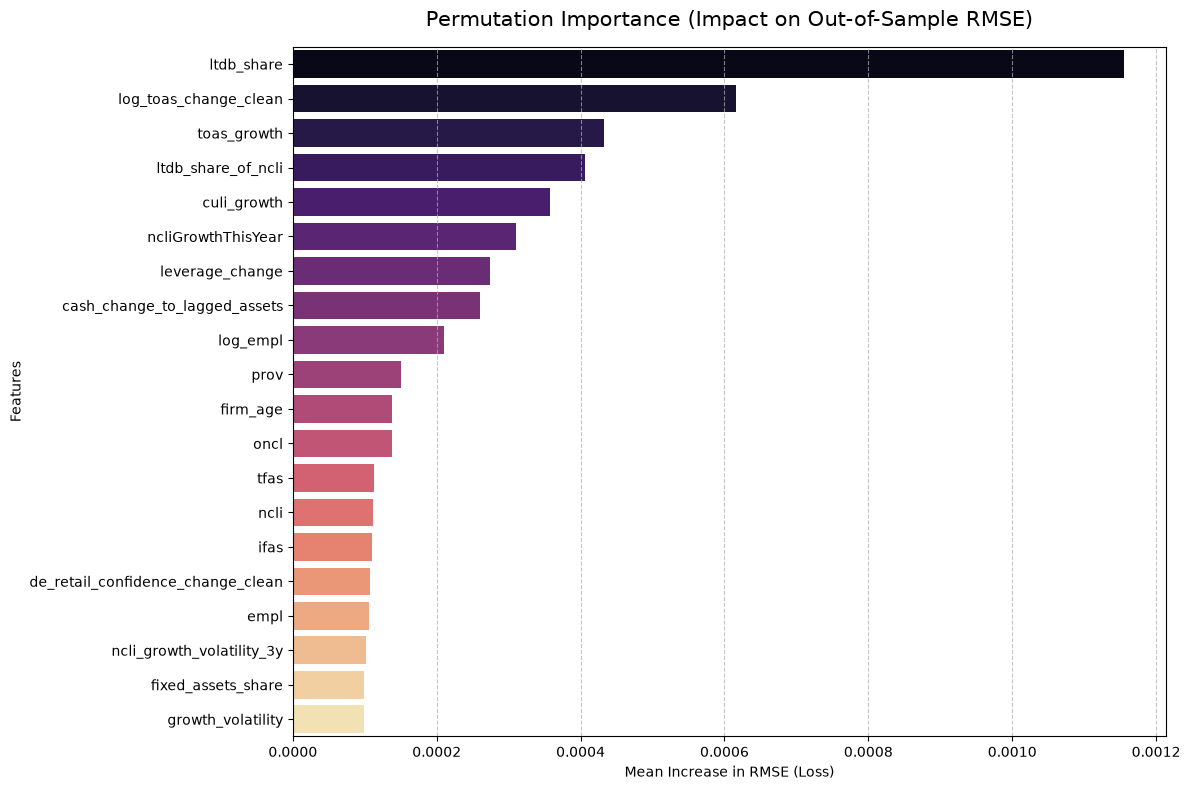

In [569]:
from sklearn.inspection import permutation_importance

# We shuffle each feature 5 times (n_repeats) and measure the drop in R2
perm_results = permutation_importance(
    final_rf_model,            
    test_df[ALL_FEATURES],     
    test_df[TARGET].values, 
    n_repeats=5, 
    random_state=42, 
    scoring='neg_root_mean_squared_error',              
    n_jobs=2,
    max_samples=0.5  # Use 50% of the test set for faster computation
)

perm_df = pd.DataFrame({
    'Feature': ALL_FEATURES,
    'Importance_Mean': perm_results.importances_mean,
    'Importance_Std': perm_results.importances_std
})

perm_df = perm_df.sort_values(by='Importance_Mean', ascending=False).reset_index(drop=True)

print("\nTop Features by Permutation Importance (RMSE Increase)")
print(perm_df.head(15).to_string(index=False))

# Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance_Mean', 
    y='Feature', 
    data=perm_df.head(20), 
    palette='magma'
)
plt.title('Permutation Importance (Impact on Out-of-Sample RMSE)', fontsize=15, pad=15)
plt.xlabel('Mean Increase in RMSE (Loss)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [570]:
import joblib
joblib.dump(final_rf_model, 'final_random_forest_model.pkl')

print("Model successfully saved to final_random_forest_model.pkl")

Model successfully saved to final_random_forest_model.pkl
